Index(['Model checkpoint', 'Number of harmonics', 'seed', 'epochs', 'recipie',
       'trained on sizes', '6,6', '9,6', '12,6', '15,3', 'error range name',
       'numberOfCodes', 'code l', 'code m', 'Date', 'recipe name',
       'rewardMaeFloor', 'curveMae', 'curveMaeP0', 'curveMaeP1', 'curveMaeP2',
       'curveMaeP3', 'curveMaeP4', 'curveMaeFloor', 'nll', 'noiseFloor',
       'rewardMae', 'kMae', 'spearman', 'kendall', 'topK50'],
      dtype='str')


C:\Users\Omer\AppData\Local\Temp\ipykernel_9128\3209144883.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


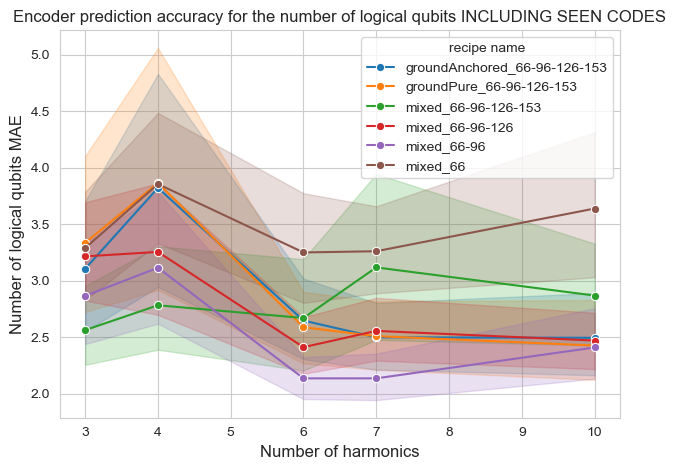

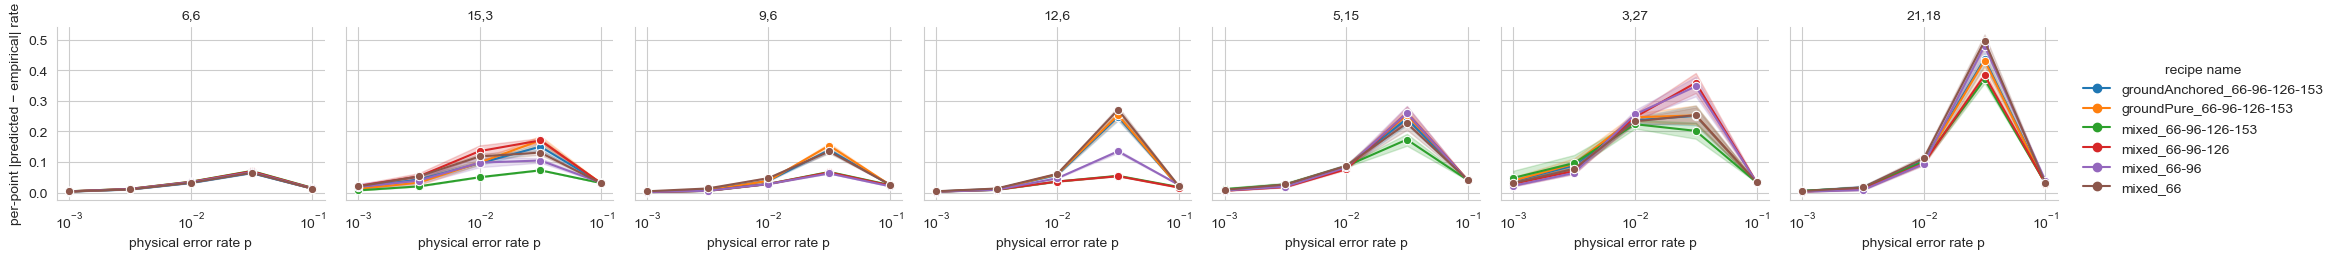

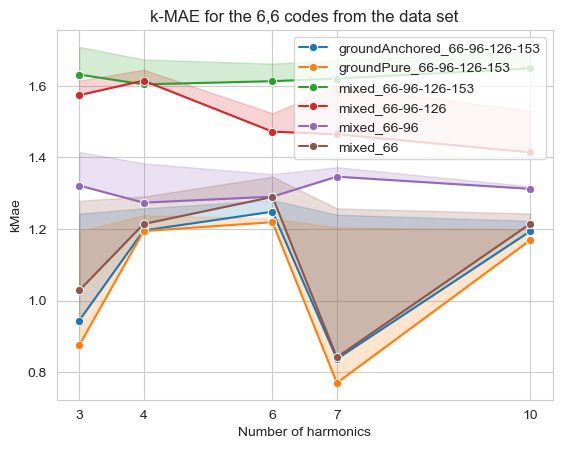

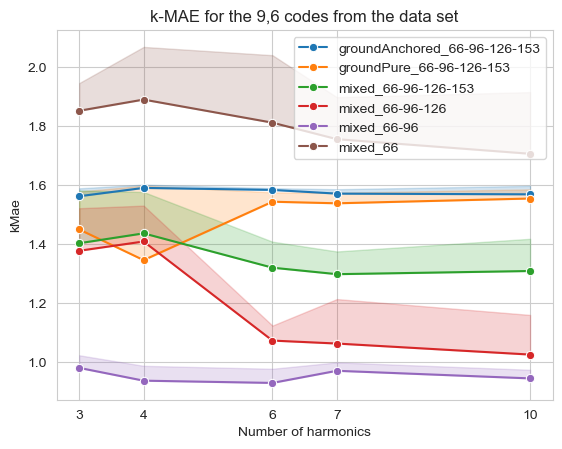

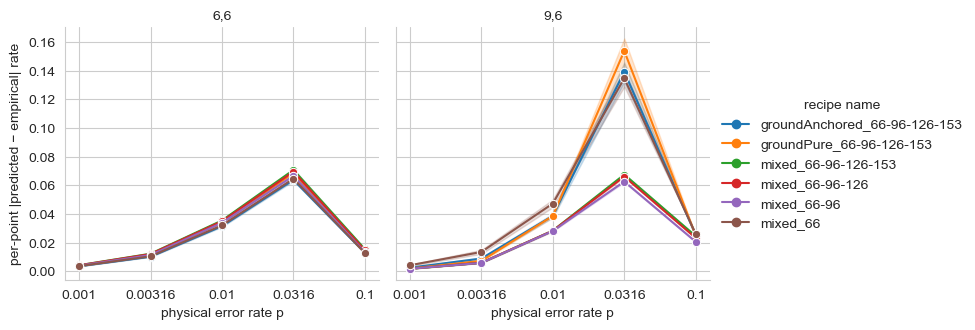

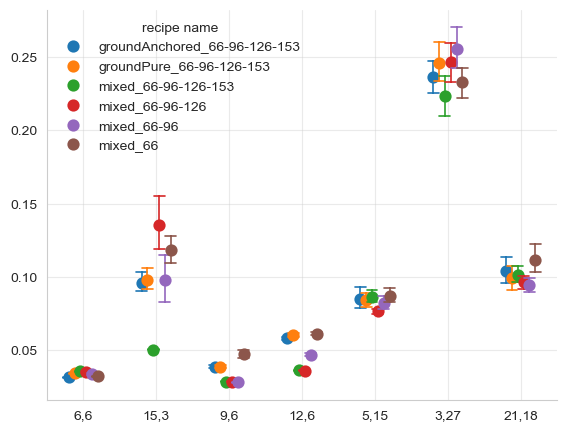

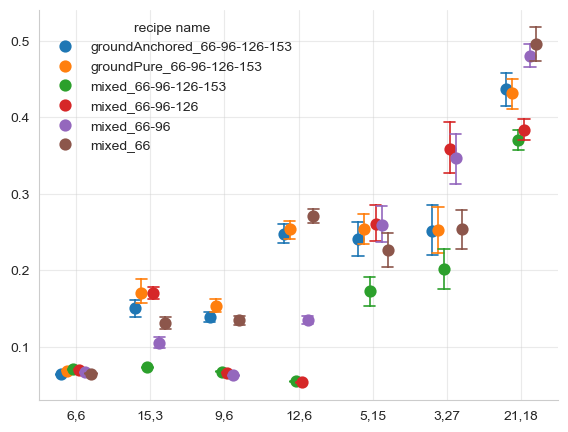

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from qecc.utils import NAMED_ERROR_RANGES
FONT_SIZE = 12
QECC_DATA = os.environ.get("QECC_DATA")
SAVE_PATH = os.path.join(os.environ.get("QECC_PAPER"), "art", "encoder")

MAKE_FIGURES_FOR_PAPER = True #If you switch this to False the figures will be generated with titles, xlabels, ylabels. If True the figures are not annotated, because that's done in the paper.

sns.set_style("whitegrid")

# ---- load the merged census -------------------------------------------------
df = pd.read_csv(os.path.join(QECC_DATA,"geometric5_sweep_encoder_recipes.csv"), sep="\t")

# drop the stray mid-file header rows (the DoC file has 2)
df = df[df["Model checkpoint"] != "Model checkpoint"]

# Convert all columns that have numeric values to numeric

pointColumns = [c for c in df.columns if re.fullmatch(r"curveMaeP\d+", c)] # all the columns relevant to error rate points
numericColumns = ["Number of harmonics", "seed", "epochs", "numberOfCodes",
                  "code l", "code m", "nll", "noiseFloor", "rewardMae", "curveMae",
                  "kMae", "spearman", "kendall", "topK50", *pointColumns]
df[numericColumns] = df[numericColumns].apply(pd.to_numeric, errors="coerce")
print(df.keys())
df["evaluationSize"] = df["code l"].astype(str) + "," + df["code m"].astype(str)

sizeOrder = sorted(df["evaluationSize"].unique(), key=lambda s: 2 * int(s.split(",")[0]) * int(s.split(",")[1]))
### First plot k-MAE 
fig, ax = plt.subplots()
sns.lineplot(data = df, x = "Number of harmonics", 
                        y = "kMae", 
                        hue = "recipe name",
                        errorbar=("ci", 95), marker="o",
                        ax = ax)
ax.set_xlabel("Number of harmonics", fontsize = FONT_SIZE)
ax.set_ylabel("Number of logical qubits MAE", fontsize = FONT_SIZE)
ax.set_title("Encoder prediction accuracy for the number of logical qubits INCLUDING SEEN CODES", fontsize = FONT_SIZE)
fig.tight_layout()
fig.show()
figName = os.path.join(SAVE_PATH, "kMAE_vs_harmonics.png")
fig.savefig(figName)

# This plot should give you kMAE plot in a matrix, columns =  code size, rows = training recipie
# g1 = sns.relplot(data = df, x = "Number of harmonics", 
#                         y = "kMae", 
#                         kind="line", 
#                         errorbar=("ci", 95), marker="o",
#                         ax = ax, col = "size", row = "recipe name", 
#                         col_order=sizeOrder)
# gridFigName = os.path.join(SAVE_PATH, "kMAE_vs_harmonics_grid.png")
# g1.savefig(gridFigName, dpi = 200)

# wide format to  long format : one row per (model, size, grid point) ---------------------
pointColumns = sorted([c for c in df.columns if re.fullmatch(r"curveMaeP\d+", c)],
                      key=lambda c: int(c[9:]))                # P0..P4 in grid order
grid = NAMED_ERROR_RANGES["geometric5"]                        # the actual p values

# I need to double check the following line. Specifically - what does df's signature looks like, waht does long's signature look like.
long = df.melt(id_vars=["recipe name", "evaluationSize", "curveMaeFloor"],
               value_vars=pointColumns,
               var_name="gridPoint", value_name="pointMae")

# Map the point data 0,1,2,3,... to their corresponding values in the error grid
long["p"] = long["gridPoint"].str[9:].astype(int).map(dict(enumerate(grid)))

# plot: MAE profile along the curve, hue = recipe, one facet per size ----
g = sns.relplot(data=long, x="p", y="pointMae", hue="recipe name",
                col="evaluationSize", col_order=sizeOrder, #col_wrap=4,
                kind="line", errorbar=("ci", 95), marker="o",
                height=2.6, aspect=1.15)
g.set(xscale="log")
g.set_axis_labels("physical error rate p", "per-point |predicted − empirical| rate")
g.set_titles("{col_name}")

# To get the "best in class" for running RL experiments using specific encoders, we want to find the model with least MAE
focusGroup = ["6,6", "9,6"]

for f in focusGroup:
    focus = df[df["evaluationSize"] == f]
    fig, ax = plt.subplots()
    ax = sns.lineplot(data=focus, 
                    estimator = "min",
                    x="Number of harmonics", 
                    y="kMae", hue="recipe name",
                    #col="evaluationSize", 
                    #kind="line", 
                    errorbar=("ci", 95), marker="o", )
                    #height=3.2, aspect=1.1)
    ax.set_xticks([3, 4, 6, 7, 10])
    ax.set_title(f"k-MAE for the {f} codes from the data set")
    ax.legend(loc="upper right")
    fig.savefig(os.path.join(SAVE_PATH, f"kMae_H_vs_recipe_for_{f}.png"))
    #g.set(xticks=[3, 4, 6, 7, 10])
    #g.set_axis_labels("Number of harmonics", "k MAE (logical qubits)")

#g._legend.set_bbox_to_anchor((0.8, 0.2))  # (x, y) position in figure coordinates
#g._legend.set_frame_on(True)              # Optional: add a frame
#g._legend.set_title("Legend")             # Optional: change title
#g._legend._loc = 1                 

#g.savefig(os.path.join(SAVE_PATH, "kMae_H_vs_recipe_for_6_6_and_9_6.png"), dpi=200)




focus = df
long = focus.melt(id_vars=["recipe name", "evaluationSize", "curveMaeFloor"],
                  value_vars=pointColumns,
                  var_name="gridPoint", value_name="pointMae")
long["p"] = long["gridPoint"].str[9:].astype(int).map(dict(enumerate(grid)))

g = sns.relplot(data=long, x="p", y="pointMae", hue="recipe name",
                col="evaluationSize", col_order=["6,6", "9,6"],
                kind="line", errorbar=("ci", 95), marker="o",
                height=3.4, aspect=1.1)
g.set(xscale="log")
g.set_axis_labels("physical error rate p", "per-point |predicted − empirical| rate")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    ax.set_xticks(grid, labels=[f"{p:.3g}" for p in grid])
    ax.minorticks_off()
g.savefig(os.path.join(SAVE_PATH, "perPointMae_focusSizes.png"), dpi=200)


longAll = df.melt(id_vars=["recipe name", "evaluationSize", "curveMaeFloor"],
                  value_vars=pointColumns,
                  var_name="gridPoint", value_name="pointMae")

for pointIndex in [2, 3]:                     # grid[2] = 0.01, grid[3] = 0.0316
    p = grid[pointIndex]
    sub = longAll[longAll["gridPoint"] == f"curveMaeP{pointIndex}"]
    g = sns.catplot(data=sub, x="evaluationSize", y="pointMae", hue="recipe name",
                    order=sizeOrder, kind="point", errorbar=("ci", 95), linestyle = "none",
                    dodge = 0.4, capsize=0.15, err_kws={"linewidth":1.2},
                    height=4.6, aspect=0.75)
    fig = g.figure
    fig.tight_layout()
    if not MAKE_FIGURES_FOR_PAPER:
        g.set_axis_labels("evaluation size (l,m)", "per-point |predicted − empirical| rate")
        g.figure.suptitle(f"p = {p:.3g}", y=1.03)
    fig.canvas.draw()                     # make the transforms current
    ax = g.axes.flat[0]
    if MAKE_FIGURES_FOR_PAPER:
            ax.set_xlabel(None)
            ax.set_ylabel(None)
    x0 = fig.transFigure.inverted().transform(ax.transData.transform((0, 0)))[0]
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.4)
    sns.move_legend(g, "upper left", bbox_to_anchor=(ax.get_position().x0 , ax.get_position().y1 ))
    
    fig.savefig(os.path.join(SAVE_PATH, f"error_point_prediction_for_point_{pointIndex}_mae_per_code_size.png"))


In [42]:
focusSizes = ["6,6", "9,6", "12,6", "15,3", "5,15", "3,27", "21,18"]
recipeOrder = ["mixed_66", "mixed_66-96", "mixed_66-96-126", "mixed_66-96-126-153",
               "groundAnchored_66-96-126-153", "groundPure_66-96-126-153"]

alignmentTable = (df.groupby(["recipe name", "evaluationSize"])[["kMae", "curveMae"]]
                        .corr(method="spearman")
                        .xs("kMae", level=-1)["curveMae"]
                        .unstack("evaluationSize")
                        .reindex(index=recipeOrder, columns=focusSizes))
alignmentTable.index.name = "recipe"
alignmentTable.columns.name = None

latexBody = (alignmentTable.style
             .format(precision=2, na_rep="--")
             .format_index(escape="latex", axis=0)
             .to_latex(hrules=True, column_format="l" + "c" * len(focusSizes)))

with open(os.path.join(SAVE_PATH, "table_k_curve_alignment_body.tex"), "w") as fid:
    fid.write(latexBody)
print(latexBody)
    

\begin{tabular}{lccccccc}
\toprule
 & 6,6 & 9,6 & 12,6 & 15,3 & 5,15 & 3,27 & 21,18 \\
recipe &  &  &  &  &  &  &  \\
\midrule
mixed\_66 & 0.36 & 0.21 & -0.05 & 0.22 & -0.46 & -0.50 & -0.10 \\
mixed\_66-96 & 0.29 & 0.47 & -0.05 & 0.39 & 0.17 & -0.62 & 0.56 \\
mixed\_66-96-126 & -0.03 & 0.61 & 0.76 & 0.70 & -0.19 & -0.39 & 0.40 \\
mixed\_66-96-126-153 & 0.03 & 0.12 & 0.34 & 0.39 & -0.53 & -0.40 & 0.06 \\
groundAnchored\_66-96-126-153 & 0.42 & 0.08 & 0.07 & -0.15 & -0.21 & -0.35 & -0.26 \\
groundPure\_66-96-126-153 & 0.34 & -0.03 & -0.00 & -0.08 & -0.12 & -0.43 & -0.23 \\
\bottomrule
\end{tabular}



In [15]:

# Get the best in class for the 6,6 and 9,6 codes:

for codeSize in ["21,18",]: #["15,3",]: #"6,6"]
    focus = df[df["evaluationSize"].isin([codeSize])].copy()
    print(len(focus)) # sanity check, should be 300
    print(f"Model selection for code size {codeSize}")
    print(f"Best models for code size {codeSize} in term of kMae:")
    #for modelName in list(map(os.path.basename, focus.nsmallest(10, "kMae")["Model checkpoint"])):
    #     print(modelName)
    # print(f"Best models for code size {codeSize} in term of curveMae:")
    # for modelName in list(map(os.path.basename, focus.nsmallest(10, "curveMae")["Model checkpoint"])):
    #     print(modelName)
    # print(f"Best models for code size {codeSize} in term of point 3 mae (0.316):")
    # for modelName in list(map(os.path.basename, focus.nsmallest(10, "curveMaeP3")["Model checkpoint"])):
    #     print(modelName)
    intersection = set(map(os.path.basename, focus.nsmallest(10, "kMae")["Model checkpoint"])).intersection(
        set(map(os.path.basename, focus.nsmallest(300, "curveMae")["Model checkpoint"]))) #.intersection(
            #set(map(os.path.basename, focus.nsmallest(12, "curveMaeP3")["Model checkpoint"])))
    print(intersection)

    #'g5_mix_66_H3_s54321.pth', 'g5_ground_anch_H3_s54321.pth', 'g5_ground_anch_H7_s466555.pth', 'g5_ground_anch_H7_s54321.pth', 'g5_ground_pure_H7_s466555.pth', 'g5_mix_66_H7_s466555.pth', 'g5_mix_66_H7_s54321.pth'
    #'g5_mix_66-96_H7_s54321.pth', 'g5_mix_66-96_H6_s3000.pth', 'g5_mix_66-96_H4_s4000.pth', 'g5_mix_66-96_H10_s2000.pth'
    

300
Model selection for code size 21,18
Best models for code size 21,18 in term of kMae:
{'g5_ground_pure_H10_s466555.pth', 'g5_mix_66-96-126-153_H10_s3000.pth', 'g5_ground_pure_H10_s6000.pth', 'g5_mix_66-96-126-153_H7_s2000.pth', 'g5_ground_anch_H10_s3000.pth', 'g5_ground_anch_H6_s6000.pth', 'g5_mix_66-96-126-153_H7_s466555.pth', 'g5_ground_anch_H10_s6000.pth', 'g5_ground_anch_H10_s4000.pth', 'g5_ground_pure_H10_s4000.pth'}


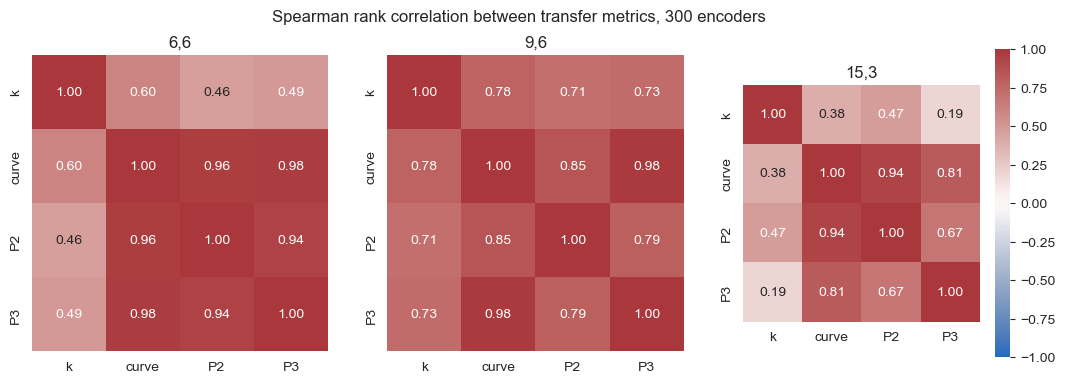

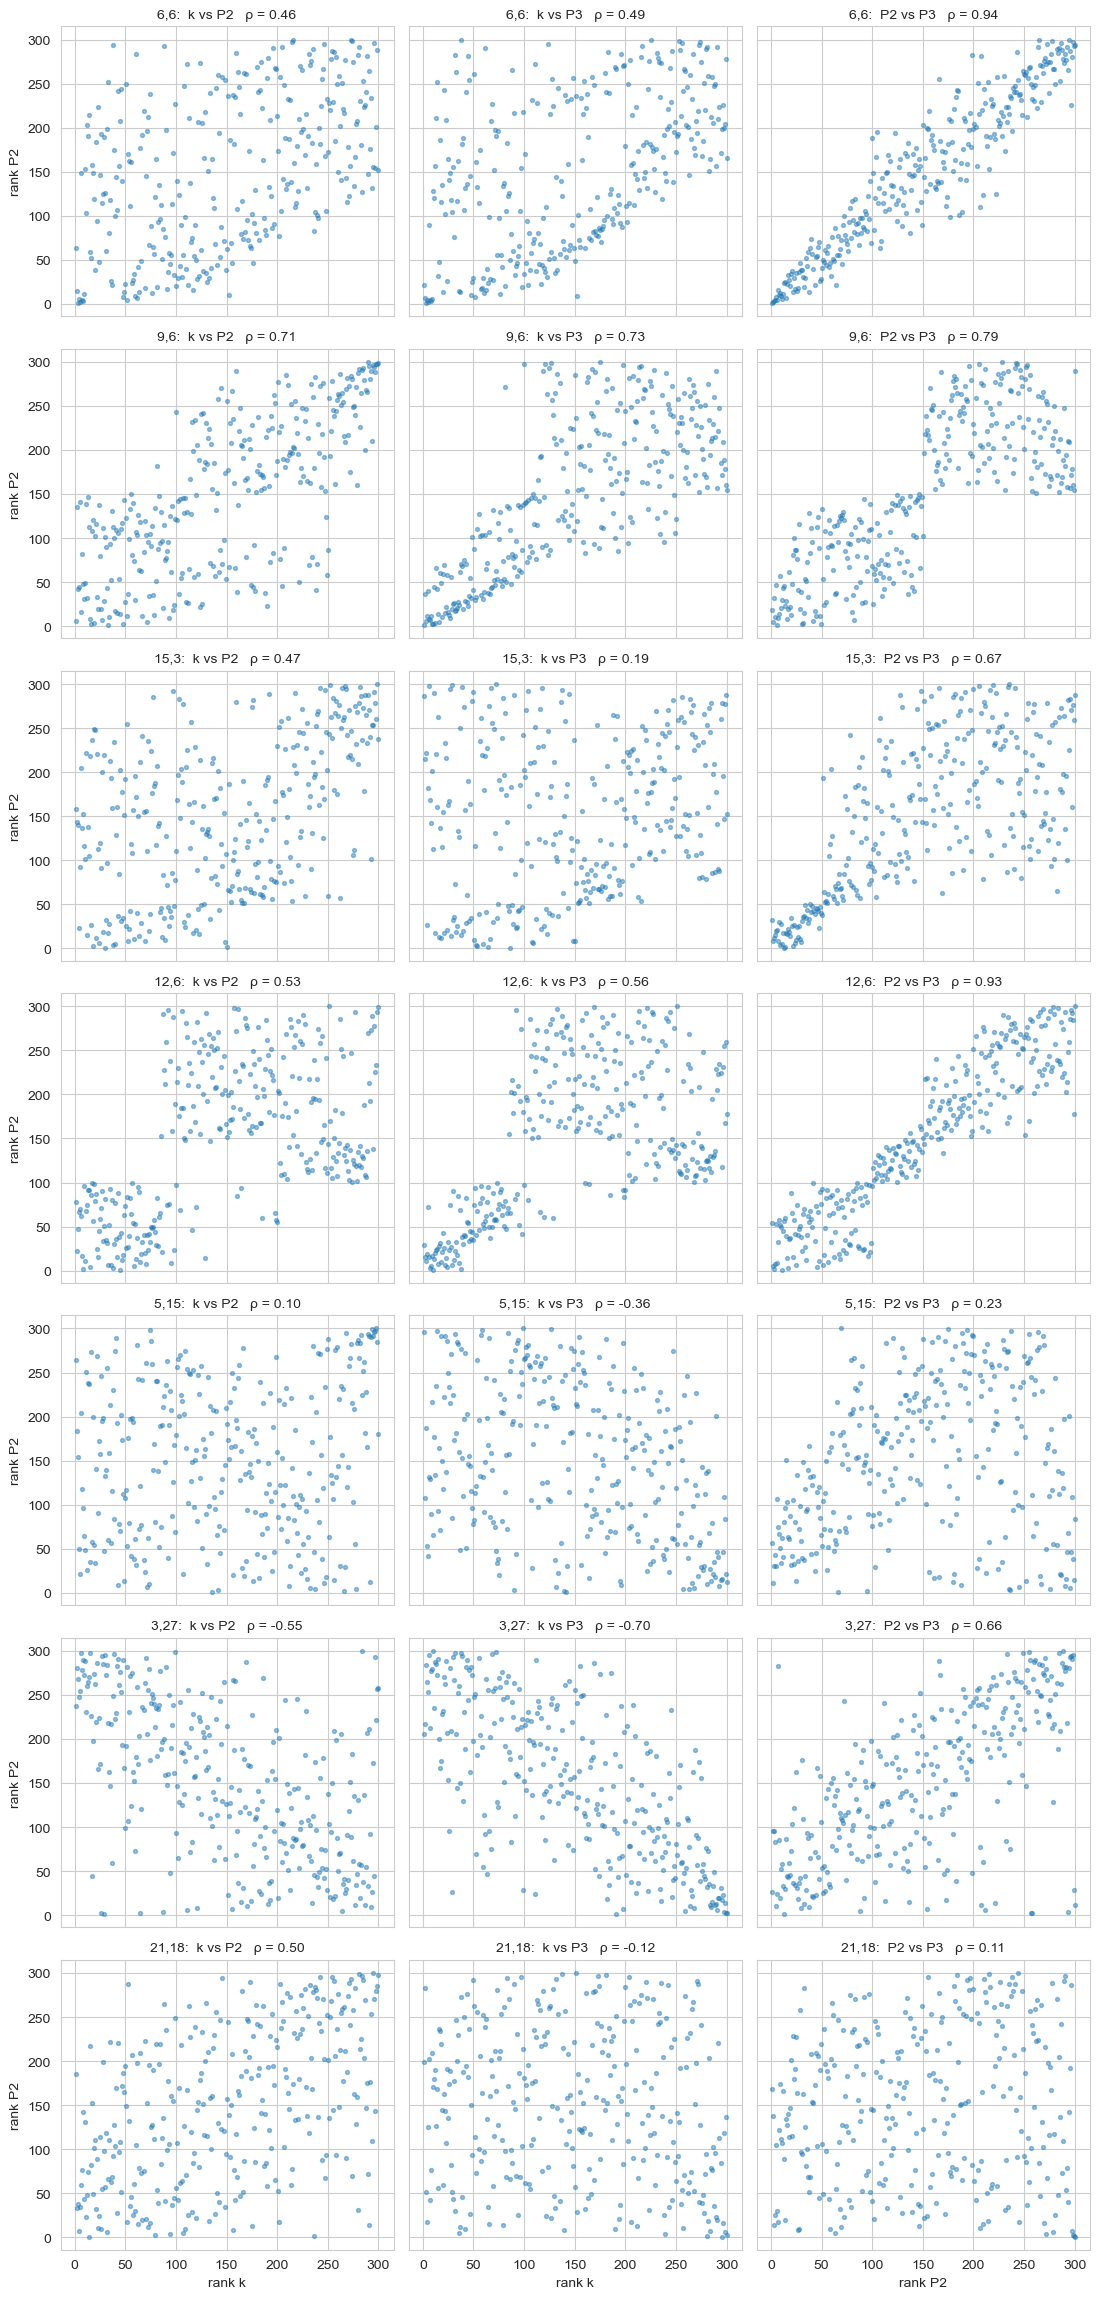

In [39]:

census = df
#sizeOrder = ["5,15", "3,27", "21,18"]         # by n

focusSizes = ["6,6", "9,6", "15,3", "12,6" ,"5,15", "3,27", "21,18"]
sizeOrder = focusSizes
metrics = ["kMae", "curveMae", "curveMaeP2", "curveMaeP3",]
labels = ["k", "curve", "P2", "P3",]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, size in zip(axes, focusSizes):
    sub = census[census["evaluationSize"] == size]
    corr = sub[metrics].corr(method="spearman")
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f",
                square=True, cbar=(ax is axes[-1]), xticklabels=labels, yticklabels=labels)
    ax.set_title(size)
fig.suptitle("Spearman rank correlation between transfer metrics, 300 encoders")
pairs = [("kMae", "curveMaeP2"), ("kMae", "curveMaeP3"), ("curveMaeP2", "curveMaeP3")]
short = {"kMae": "k", "curveMaeP2": "P2", "curveMaeP3": "P3"}

fig, axes = plt.subplots(len(focusSizes), len(pairs),
                         figsize=(3.7 * len(pairs), 3.3 * len(focusSizes)),
                         sharex=True, sharey=True, squeeze=False)
for i, size in enumerate(focusSizes):
    sub = census[census["evaluationSize"] == size]
    ranks = sub[list(short)].rank(method="min")
    for j, (a, b) in enumerate(pairs):
        ax = axes[i, j]
        ax.scatter(ranks[a], ranks[b], s=8, alpha=0.45)
        rho = sub[[a, b]].corr(method="spearman").iloc[0, 1]
        ax.set_title(f"{size}:  {short[a]} vs {short[b]}   ρ = {rho:.2f}", fontsize=10)
        if i == len(focusSizes) - 1:
            ax.set_xlabel(f"rank {short[a]}")
        if j == 0:
            ax.set_ylabel(f"rank {short[b]}")
fig.tight_layout()

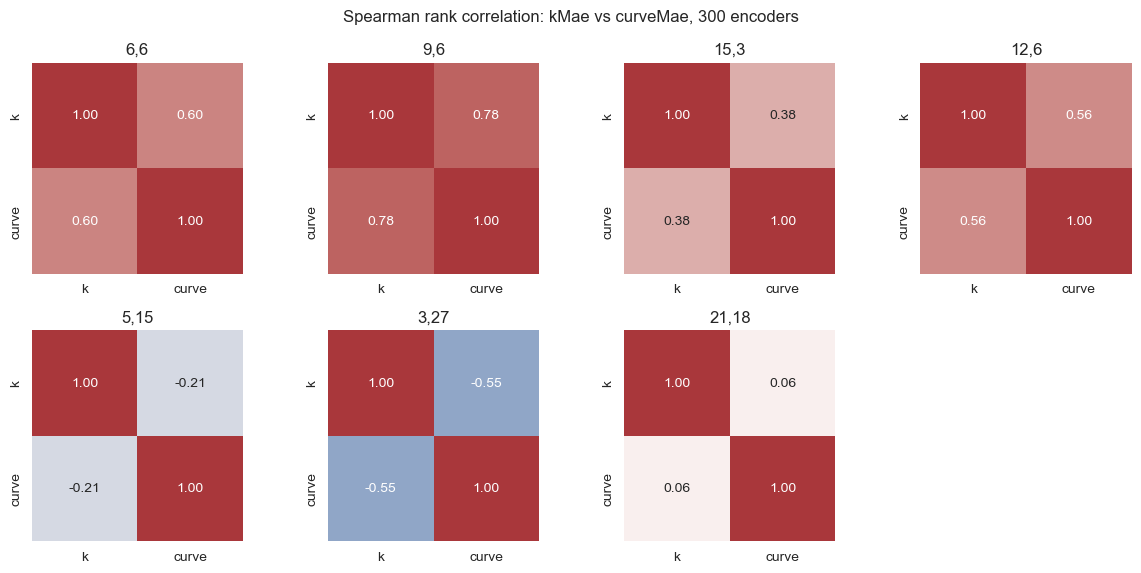

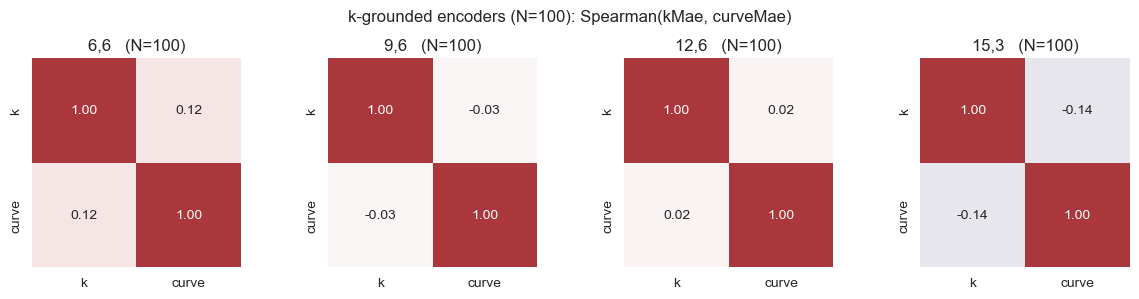

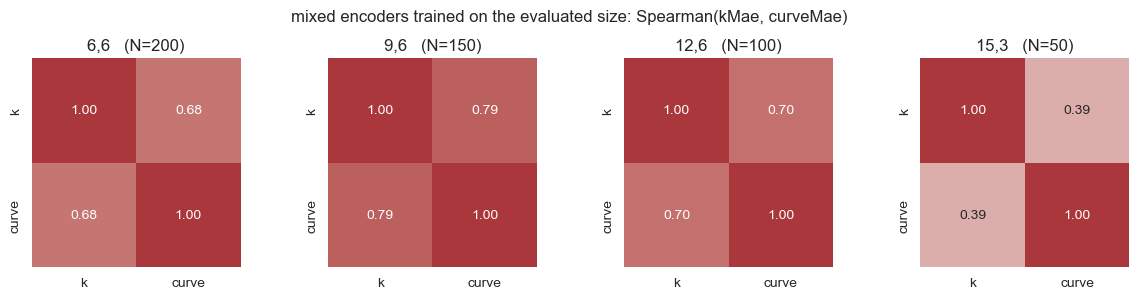

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

focusSizes = ["6,6", "9,6", "15,3", "12,6", "5,15", "3,27", "21,18"]
metrics = ["kMae", "curveMae"]
labels = ["k", "curve"]

nCols = 4
nRows = int(np.ceil(len(focusSizes) / nCols))
fig, axes = plt.subplots(nRows, nCols, figsize=(3.0 * nCols, 2.9 * nRows), squeeze=False)

for ax, size in zip(axes.flat, focusSizes):
    sub = census[census["evaluationSize"] == size]
    corr = sub[metrics].corr(method="spearman")
    sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f",
                square=True, cbar=False, xticklabels=labels, yticklabels=labels)
    ax.set_title(size)

for ax in axes.flat[len(focusSizes):]:      # blank the unused 8th slot
    ax.set_visible(False)

fig.suptitle("Spearman rank correlation: kMae vs curveMae, 300 encoders")
fig.tight_layout()
plt.show()

gridSizes = ["6,6", "9,6", "12,6", "15,3"]

def rankCorrHeatmaps(frame, sizes, title, nCols=4):
    nRows = int(np.ceil(len(sizes) / nCols))
    fig, axes = plt.subplots(nRows, nCols, figsize=(3.0 * nCols, 2.9 * nRows), squeeze=False)
    for ax, size in zip(axes.flat, sizes):
        sub = frame[frame["evaluationSize"] == size]
        corr = sub[["kMae", "curveMae"]].corr(method="spearman")
        sns.heatmap(corr, ax=ax, vmin=-1, vmax=1, cmap="vlag", annot=True, fmt=".2f",
                    square=True, cbar=False,
                    xticklabels=["k", "curve"], yticklabels=["k", "curve"])
        ax.set_title(f"{size}   (N={len(sub)})")
    for ax in axes.flat[len(sizes):]:
        ax.set_visible(False)
    fig.suptitle(title)
    fig.tight_layout()

# --- Figure A: the 100 k-grounded encoders (groundAnchored + groundPure) ---------
grounded = census[census["recipie"].str.startswith("ground")]
rankCorrHeatmaps(grounded, gridSizes,
                 "k-grounded encoders (N=100): Spearman(kMae, curveMae)")

# --- Figure B: mixed-recipe encoders whose training mix included the evaluated size
parts = []
for size in gridSizes:
    parts.append(census[(census["recipie"] == "mixed")
                        & (census[size].astype(str) == "True")
                        & (census["evaluationSize"] == size)])
fullTrained = pd.concat(parts)
rankCorrHeatmaps(fullTrained, gridSizes,
                 "mixed encoders trained on the evaluated size: Spearman(kMae, curveMae)")

plt.show()